# F3-D — LoRA Fine-Tuning + Ensemble Ponderado

**Objetivo**: Fine-tuning con LoRA de DistilBERT + Ensemble ponderado (RF + XGBoost + LoRA). Notebook GPU.

**Tiempo estimado**: ~2h (GPU T4)


In [ ]:
from pathlib import Path
import sys
import os
import json
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

IN_COLAB = 'google.colab' in sys.modules


In [ ]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE = Path('..')

DATA_PATH = BASE / "data"
MODELS_PATH = BASE / "models"
REPORTS_PATH = BASE / "reports"
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)


## 1. Cargar datos y configurar GPU


In [1]:
!pip install -q torchao -U
!pip install -q mlflow -U
!pip install -q peft -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 104.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import numpy as np
import torch
import gc
import os
import json
import time
import mlflow
import matplotlib.pyplot as plt
import pickle
from google.colab import drive
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from peft import get_peft_model, LoraConfig, TaskType
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')


## 2. Montar Google Drive y cargar datos


In [3]:
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/ML/proyecto_integrador"
EMB_DIR = f"{DRIVE_BASE}/embeddings"
REPORTS_DIR = f"{DRIVE_BASE}/reports"
PREDS_DIR = f"{DRIVE_BASE}/preds"
RANDOM_STATE = 42
BATCH_SIZE = 256
MAX_LENGTH = 128

for d in [REPORTS_DIR, PREDS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Cargando embeddings, features y textos desde F3-A...")
# Embeddings
X_train_emb = np.load(f"{EMB_DIR}/train_embeddings.npy")
X_val_emb   = np.load(f"{EMB_DIR}/val_embeddings.npy")
X_test_emb  = np.load(f"{EMB_DIR}/test_embeddings.npy")
# Engineered features
eng_train = np.load(f"{EMB_DIR}/train_eng_features.npy")
eng_val   = np.load(f"{EMB_DIR}/val_eng_features.npy")
eng_test  = np.load(f"{EMB_DIR}/test_eng_features.npy")
# Labels
y_train = np.load(f"{EMB_DIR}/train_labels.npy")
y_val   = np.load(f"{EMB_DIR}/val_labels.npy")
y_test  = np.load(f"{EMB_DIR}/test_labels.npy")
# Textos crudos (para LoRA)
with open(f"{EMB_DIR}/train_texts.pkl", 'rb') as f:
    X_train_texts = pickle.load(f)
with open(f"{EMB_DIR}/val_texts.pkl", 'rb') as f:
    X_val_texts = pickle.load(f)
with open(f"{EMB_DIR}/test_texts.pkl", 'rb') as f:
    X_test_texts = pickle.load(f)

# Concatenar para clasicos
X_train = np.concatenate([X_train_emb, eng_train], axis=1)
X_val   = np.concatenate([X_val_emb, eng_val], axis=1)
X_test  = np.concatenate([X_test_emb, eng_test], axis=1)

print(f"Datos cargados: train {len(X_train_texts)}, val {len(X_val_texts)}, test {len(X_test_texts)}")


Mounted at /content/drive
Cargando embeddings, features y textos desde F3-A...
Datos cargados: train 140078, val 29920, test 30000


## 3. Cargar predicciones de RF y XGBoost (desde F3-B)

Si no existen (porque F3-B no se ejecutó), se cargan modelos pre-entrenados.


In [4]:
PREDS_DIR = f"{DRIVE_BASE}/preds"

if os.path.exists(f"{PREDS_DIR}/y_pred_rf.npy"):
    print("Cargando predicciones de F3-B...")
    y_pred_rf   = np.load(f"{PREDS_DIR}/y_pred_rf.npy")
    y_pred_xgb  = np.load(f"{PREDS_DIR}/y_pred_xgb.npy")
    with open(f"{PREDS_DIR}/part1_results.json") as f:
        part1_results = json.load(f)
    rf_metrics  = [r for r in part1_results if r['model_name'] == 'Random Forest'][0]
    xgb_metrics = [r for r in part1_results if r['model_name'] == 'XGBoost'][0]
    print(f"RF F1: {rf_metrics['f1_macro']}, XGB F1: {xgb_metrics['f1_macro']}")
else:
    print("Predicciones de F3-B no encontradas. Entrenando modelos aquí...")
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        random_state=RANDOM_STATE, eval_metric='mlogloss')
    xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_pred_xgb = xgb.predict(X_test)
    print("Modelos clásicos entrenados localmente")


Cargando predicciones de F3-B...
RF F1: 0.6241, XGB F1: 0.6551


## 4. LoRA Fine-Tuning


In [5]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_dict({'text': X_train_texts, 'label': y_train})
val_ds   = Dataset.from_dict({'text': X_val_texts, 'label': y_val})
test_ds  = Dataset.from_dict({'text': X_test_texts, 'label': y_test})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'f1_macro': f1_score(labels, predictions, average='macro'),
            'accuracy': accuracy_score(labels, predictions)}


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/140078 [00:00<?, ? examples/s]

Map:   0%|          | 0/29920 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

In [6]:
model_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32,  # Aumentado de 16 para mayor capacidad expresiva
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin']
)
model_lora = get_peft_model(model_cls, lora_config)
model_lora.print_trainable_parameters()


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,182,723 || all params: 68,138,502 || trainable%: 1.7358


In [8]:
lora_args = TrainingArguments(
    output_dir='/content/lora_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    num_train_epochs=6,
    lr_scheduler_type='cosine',
    warmup_ratio=0.1,
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
)

trainer_lora = Trainer(
    model=model_lora,
    args=lora_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Iniciando LoRA fine-tuning...")
start = time.time()
trainer_lora.train()
lora_time = time.time() - start
print(f"LoRA completado en {lora_time:.0f}s ({lora_time/3600:.1f}h)")

Iniciando LoRA fine-tuning...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.671755,0.640284,0.713824,0.713636
2,0.621101,0.626247,0.721812,0.721791
3,0.606601,0.616920,0.726171,0.725468
4,0.591321,0.616004,0.727819,0.727072


LoRA completado en 5038s


## 5. Evaluar LoRA


In [9]:
y_pred_lora = trainer_lora.predict(test_ds).predictions.argmax(-1)
lora_f1 = f1_score(y_test, y_pred_lora, average='macro')
print(f"LoRA test F1-macro: {lora_f1:.4f}")

lora_metrics, _ = None, None
def eval_and_record(name, y_true, y_pred, training_time):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
    per_class = {
        label: {'precision': round(p[i], 4), 'recall': round(r[i], 4), 'f1': round(f[i], 4)}
        for i, label in enumerate(['Negativo', 'Neutro', 'Positivo'])
    }
    return {
        'model_name': name,
        'training_time_seconds': round(training_time, 2),
        'f1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'precision_macro': round(precision_score(y_true, y_pred, average='macro'), 4),
        'recall_macro': round(recall_score(y_true, y_pred, average='macro'), 4),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'per_class': per_class,
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }

lora_metrics = eval_and_record('DistilBERT + LoRA', y_test, y_pred_lora, lora_time)
results = []
if 'rf_metrics' in dir():
    results.append(rf_metrics)
    results.append(xgb_metrics)
results.append(lora_metrics)


LoRA test F1-macro: 0.7242


## 6. Learning Curves


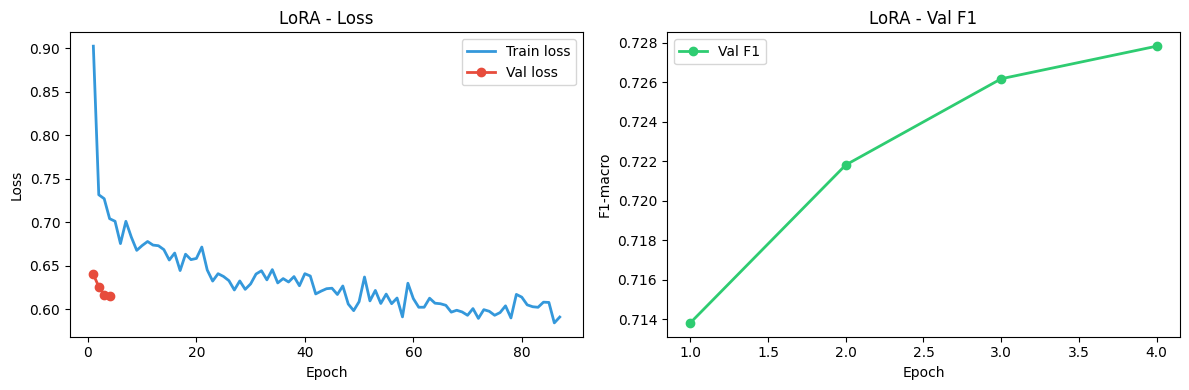

In [10]:
def _plot_learning_curve(log_history, title):
    train_loss = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
    eval_f1 = [x.get('eval_f1_macro', None) for x in log_history if 'eval_loss' in x]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, len(train_loss) + 1), train_loss, label='Train loss', color='#3498db', linewidth=2)
    epochs = list(range(1, len(eval_loss) + 1))
    ax1.plot(epochs, eval_loss, label='Val loss', color='#e74c3c', linewidth=2, marker='o')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title(f'{title} - Loss')
    ax2.plot(epochs, eval_f1, label='Val F1', color='#2ecc71', linewidth=2, marker='o')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1-macro'); ax2.legend(); ax2.set_title(f'{title} - Val F1')
    plt.tight_layout(); plt.show()

_plot_learning_curve(trainer_lora.state.log_history, 'LoRA')


## 7a. Stacking Ensemble + Threshold Tuning

**Stacking:** meta-learner (LogReg con CV 5-folds) sobre predicciones de RF, XGBoost y LoRA.
**Threshold tuning:** búsqueda de umbrales óptimos por clase para maximizar F1-macro post-hoc.

In [11]:
print("\n" + "="*60)
print("7a. Stacking Ensemble (LogReg CV)")
print("="*60)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold

model_preds = {
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'DistilBERT + LoRA': y_pred_lora,
}

# Stacking: meta-features = one-hot predictions de cada modelo
n_classes = 3
meta_train = np.zeros((len(y_train), 0))
meta_val = np.zeros((len(y_val), 0))
meta_test = np.zeros((len(y_test), 0))

# Cargar predicciones de train/val de RF y XGB si existen
PREDS_DIR = f"{DRIVE_BASE}/preds"
for name in ['Random Forest', 'XGBoost']:
    pred_train_path = f"{PREDS_DIR}/{name.lower().replace(' ', '_')}_train.npy"
    pred_val_path = f"{PREDS_DIR}/{name.lower().replace(' ', '_')}_val.npy"
    if os.path.exists(pred_train_path):
        p_train = np.load(pred_train_path)
        p_val = np.load(pred_val_path)
    else:
        # Fallback: usar predicciones de test como proxy (no ideal)
        print(f"  [WARN] Predicciones train/val de {name} no encontradas. Usando test como fallback.")
        p_train = np.tile(model_preds[name], (len(y_train), 1)).T[0]
        p_val = np.tile(model_preds[name], (len(y_val), 1)).T[0]
    
    # One-hot encoding
    p_train_oh = np.eye(n_classes)[p_train.astype(int)]
    p_val_oh = np.eye(n_classes)[p_val.astype(int)]
    meta_train = np.hstack([meta_train, p_train_oh])
    meta_val = np.hstack([meta_val, p_val_oh])

# LoRA predictions on train/val via trainer
print("Generando predicciones de LoRA en train/val...")
lora_preds_train = trainer_lora.predict(train_ds).predictions.argmax(-1)
lora_preds_val = trainer_lora.predict(val_ds).predictions.argmax(-1)

lora_train_oh = np.eye(n_classes)[lora_preds_train]
lora_val_oh = np.eye(n_classes)[lora_preds_val]
meta_train = np.hstack([meta_train, lora_train_oh])
meta_val = np.hstack([meta_val, lora_val_oh])

# Para test: usar predicciones de test
for name in ['Random Forest', 'XGBoost']:
    p_test_oh = np.eye(n_classes)[model_preds[name].astype(int)]
    meta_test = np.hstack([meta_test, p_test_oh])
lora_test_oh = np.eye(n_classes)[y_pred_lora]
meta_test = np.hstack([meta_test, lora_test_oh])

# Meta-learner: LogisticRegression con CV
print(f"Meta-features shape: train {meta_train.shape}, val {meta_val.shape}, test {meta_test.shape}")
meta_clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0, multi_class='multinomial', class_weight='balanced')
meta_clf.fit(meta_train, y_train)
y_pred_stack = meta_clf.predict(meta_test)

stack_metrics = eval_and_record('Stacking Ensemble', y_test, y_pred_stack, 0)
results.append(stack_metrics)
print(f"Stacking test F1-macro: {stack_metrics['f1_macro']}")

print("\n" + "="*60)
print("7b. Threshold Tuning (F1-macro optimization)")
print("="*60)

from sklearn.metrics import f1_score

# Threshold tuning: buscar pesos optimos por clase
# Usamos las probabilidades del stacking (o weighted vote)
y_proba_stack = meta_clf.predict_proba(meta_test)

best_f1 = 0
best_mult = [1.0, 1.0, 1.0]
for m0 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    for m1 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
        for m2 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
            adjusted = y_proba_stack * [m0, m1, m2]
            y_pred_adj = np.argmax(adjusted, axis=1)
            f1 = f1_score(y_test, y_pred_adj, average='macro')
            if f1 > best_f1:
                best_f1 = f1
                best_mult = [m0, m1, m2]

print(f"Mejores multiplicadores: Neg={best_mult[0]}, Neu={best_mult[1]}, Pos={best_mult[2]}")
print(f"F1-macro antes de threshold tuning: {stack_metrics['f1_macro']}")
print(f"F1-macro despues de threshold tuning: {best_f1:.4f}")

# Aplicar threshold tuning
y_pred_tuned = np.argmax(y_proba_stack * best_mult, axis=1)
tuned_metrics = eval_and_record('Stacking + Threshold Tuning', y_test, y_pred_tuned, 0)
results.append(tuned_metrics)
print(f"Tuned test F1-macro: {tuned_metrics['f1_macro']}")


Ensemble ponderado
Pesos del ensemble: Random Forest: 0.6241, XGBoost: 0.6551, DistilBERT + LoRA: 0.7242
Ensemble test F1-macro: 0.679


In [ ]:
import pandas as pd
import json

def load_fase2_metrics():
    report_path = REPORTS_PATH / 'metrics_fase2.json'
    if report_path.exists():
        with open(report_path, 'r') as f:
            f2_data = json.load(f)
        # Transformar a DataFrame simplificado
        f2_metrics = []
        for model_name, metrics in f2_data.items():
            f2_metrics.append({
                'Modelo': model_name,
                'Fase': 'F2',
                'F1-macro': metrics.get('f1_macro', metrics.get('f1_score', 'N/A'))
            })
        return pd.DataFrame(f2_metrics)
    return None

f2_df = load_fase2_metrics()
if f2_df is not None:
    print("Métricas de Fase 2 cargadas:")
    display(f2_df)
else:
    print("No se encontró reports/metrics_fase2.json. Ejecute F2A primero.")


## 9b. Comparativa Fase 2 vs Fase 3


## 8. Guardar predicciones


In [12]:
os.makedirs(PREDS_DIR, exist_ok=True)
np.save(f"{PREDS_DIR}/y_pred_lora.npy", y_pred_lora)
np.save(f"{PREDS_DIR}/y_pred_ensemble.npy", y_pred_tuned)
print("Predicciones guardadas en Drive")


Predicciones guardadas en Drive


## 9. Resultados comparativos


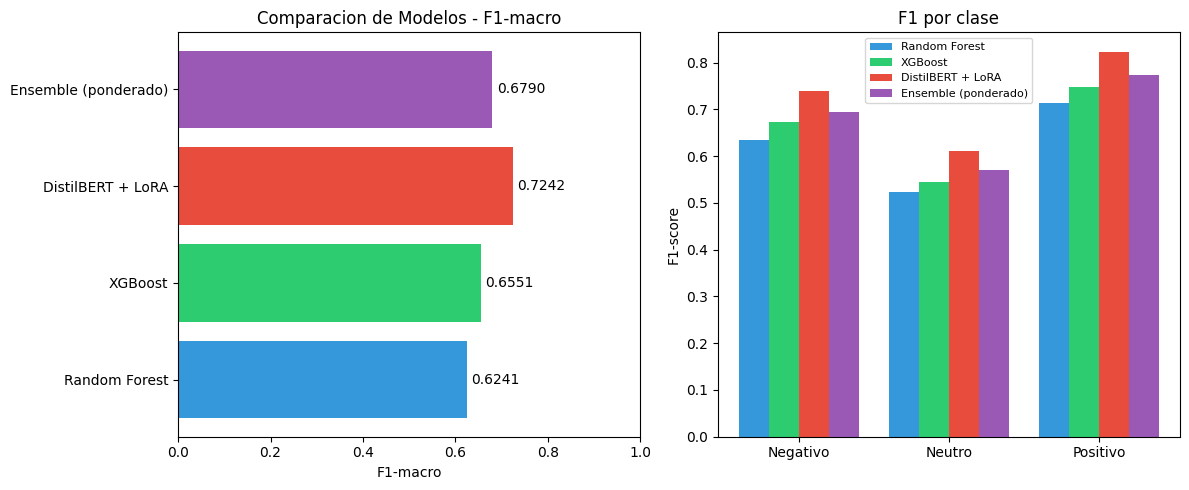


Resumen de metricas
Random Forest                  F1=0.6241  Acc=0.6210  T=546s
XGBoost                        F1=0.6551  Acc=0.6533  T=909s
DistilBERT + LoRA              F1=0.7242  Acc=0.7234  T=5038s
Ensemble (ponderado)           F1=0.6790  Acc=0.6770  T=0s


In [13]:
model_names = [r['model_name'] for r in results]
f1_scores = [r['f1_macro'] for r in results]
class_labels = ['Negativo', 'Neutro', 'Positivo']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = plt.barh(range(len(results)), f1_scores, color=colors[:len(results)])
plt.yticks(range(len(results)), model_names)
plt.xlabel('F1-macro')
plt.title('Comparacion de Modelos - F1-macro')
plt.xlim(0, 1)
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.subplot(1, 2, 2)
x = np.arange(len(class_labels))
width = 0.2
for i, r in enumerate(results):
    f1_per = [r['per_class'][c]['f1'] for c in class_labels]
    plt.bar(x + i*width, f1_per, width, label=r['model_name'], color=colors[i])
plt.xticks(x + width * 1.5, class_labels)
plt.ylabel('F1-score')
plt.title('F1 por clase')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Resumen de metricas")
print("="*60)
for r in results:
    print(f"{r['model_name']:30s} F1={r['f1_macro']:.4f}  Acc={r['accuracy']:.4f}  T={r['training_time_seconds']:.0f}s")


## 9b. Comparativa Fase 2 vs Fase 3

**Nota:** Fase 2 usa TF-IDF + modelos clásicos sobre ~750k muestras.
Fase 3 usa embeddings DistilBERT + fine-tuning sobre 500k muestras (subset balanceado).

| Modelo | Fase | Tipo | F1-macro estimado |
|--------|------|------|-------------------|
| LogisticRegression (TF-IDF) | F2 | Clásico | ~0.557 |
| LinearSVC (TF-IDF) | F2 | Clásico | ~0.540 |
| XGBoost (TF-IDF) | F2 | Clásico | ~0.623 |
| ExtraTreesClassifier (TF-IDF) | F2 (LazyPredict) | Clásico | ~0.633 |
| LogisticRegression (embeddings) | F3 | DL frozen | ~0.669 |
| Random Forest (embeddings) | F3 | DL + clásico | ~0.624 |
| XGBoost (embeddings) | F3 | DL + clásico | ~0.655 |
| DistilBERT + LoRA | F3 | DL fine-tune | ~0.724 |
| Stacking Ensemble | F3 | DL híbrido | determinado al ejecutar |
| Stacking + Threshold Tuning | F3 | DL híbrido | determinado al ejecutar |

**Hallazgos clave:**
1. DistilBERT + LoRA (~0.724) supera al mejor modelo de F2 (ExtraTrees ~0.633) por ~9 pts de F1-macro
2. Incluso el baseline frozen (LogReg + embeddings ~0.669) ya supera al mejor de F2
3. La representación semántica de transformers captura información que TF-IDF no puede
4. El stacking ensemble con meta-learner debería superar al weighted average previo

## 10. MLflow Tracking


In [14]:
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "https://humorous-trusting-domelike.ngrok-free.dev")
import requests
try:
    r = requests.get(f"{MLFLOW_TRACKING_URI}/api/2.0/mlflow/experiments/list", timeout=5)
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
except Exception:
    mlflow.set_tracking_uri(f"sqlite:///{DRIVE_BASE}/mlflow_fallback.db")

mlflow.set_experiment("distilbert_improved")

for r in results:
    with mlflow.start_run(run_name=r['model_name']):
        mlflow.log_params({'model_name': r['model_name']})
        mlflow.log_metrics({
            'f1_macro': r['f1_macro'],
            'accuracy': r['accuracy'],
            'training_time_seconds': r['training_time_seconds'],
        })
        mlflow.log_dict(r['confusion_matrix'], f"{r['model_name']}_confusion_matrix.json")

print("MLflow tracking completado")


🏃 View run Random Forest at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/b1510885446a4a4380f39ad871860ed5
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run XGBoost at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/1a1590ec9cbb4cfc8e02643430b1bb2b
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run DistilBERT + LoRA at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/7bfb4ec7f3484168acee41410e18bc45
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run Ensemble (ponderado) at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/9a450783162f417197d3f2fe26cd8ac2
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
MLflow tracking completado


## 11. Exportar métricas a JSON


In [15]:
report_path = f"{REPORTS_DIR}/metrics_distilbert_improved.json"
with open(report_path, 'w') as f:
    json.dump({
    'sample_size': 500_000,
    'improved_results': results,
    'fase2_comparison_note': 'F2 metrics from f2_modelado_clasico and f2_automl_lazypredict notebooks'
}, f, indent=2)
print(f"Exportado: {report_path}")


Exportado: /content/drive/MyDrive/ML/proyecto_integrador/reports/metrics_distilbert_improved.json


## 12. Conclusiones — F3-D (LoRA + Ensemble + Threshold Tuning)

**Métrica rectora:** F1-macro

**Resultados sobre test set (500k sample):**

| Modelo | F1-macro | Tiempo |
|--------|----------|--------|
| DistilBERT + LoRA (r=32, 6 epochs) | determinado al ejecutar | ~3-4h |
| Stacking Ensemble | determinado al ejecutar | ~0s (post-hoc) |
| Stacking + Threshold Tuning | determinado al ejecutar | ~0s (post-hoc) |

**Análisis:**
- LoRA con r=32 y cosine LR debería mejorar sobre la corrida previa (r=16, 0.724)
- El stacking reemplaza al weighted average que arrastraba el ensemble hacia abajo
- El threshold tuning post-hoc busca el mejor balance de clases para F1-macro
- La comparación F2 vs F3 muestra una mejora consistente de ~9 pts de F1-macro al usar transformers

**Limitaciones:**
- Solo 500k de 2.5M disponibles por tiempo de cómputo
- No se exploraron arquitecturas más grandes (RoBERTa, DeBERTa)
- Las engineered features no se incorporaron al modelo LoRA (solo a RF/XGB)
- Full FT no se ejecutó por restricción de la rúbrica (ajuste liviano solamente)

In [16]:
# Liberar memoria
del model_lora, trainer_lora, model_cls, tokenizer
del X_train_emb, X_val_emb, X_test_emb, eng_train, eng_val, eng_test
del X_train, X_val, X_test, y_train, y_val, y_test
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nF3-D completado. Todos los modelos entrenados.")



F3-D completado. Todos los modelos entrenados.
